#Lab 02 - DataFrame Basics

Untuk rangkaian latihan ini kita akan mengolah dan menganalisis data AirBnB New York. Data didapatkan dari link ini (https://www.kaggle.com/dgomonov/data-exploration-on-nyc-airbnb) dengan beberapa penyesuaian.

Dalam Lab 02 ini kita akan melakukan loading file csv, kemudian melakukan eksplorasi data untuk melihat langkah data cleansing apa yang perlu dilakukan.

Beberapa hal yang perlu diperhatikan:

1. Adakah kolom yang tidak diperlukan, yang bisa dihapus?
2. Adakah data yang hilang/null? Apa yang harus kita lakukan terhadapnya?
3. Apakah ada data duplikat, dan apa yang harus dilakukan untuk mengolahnya?

Langkah pengolahan dataset
- Loading csv file
- Quick check
- Akses dengan berbagai metode

Berikut ini beberapa pertanyaan untuk latihan :
1. Ada berapa row dan berapa kolom data yang di-load?
2. Apa saja nama kolomnya?
3. Tampilkan data dari baris ke 11 sampai ke 20
4. Tampilkan data dari kolom ke 3 sampai ke 6
5. Berapa nilai rata-rata, maksimum dan minimum untuk kolom2 tertentu?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading data dari file csv.

In [2]:
filename = 'https://raw.githubusercontent.com/urfie/DataAnalytics/main/airbnb_nyc_toclean.csv'
df = pd.read_csv(filename)
df.head()

,index,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
1,2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
2,3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
3,4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
4,5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129


Melakukan *Quick Checking* untuk melihat sekilas profil dataset.

In [38]:
# tampilkan shape (dimensi) dari DataFrame

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 48940
Jumlah kolom : 16


In [39]:
# tampilkan nama kolom dari DataFrame

list(df.columns)

['index',
 'id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [40]:
# tampilkan informasi kolom dari DataFrame
# hints: gunakan fungsi info()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48940 entries, 0 to 48944
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   index                           48940 non-null  int64  
 1   id                              48940 non-null  int64  
 2   name                            48924 non-null  object 
 3   host_id                         48940 non-null  int64  
 4   host_name                       48919 non-null  object 
 5   neighbourhood                   48940 non-null  object 
 6   latitude                        48940 non-null  float64
 7   longitude                       48940 non-null  float64
 8   room_type                       48940 non-null  object 
 9   price                           48940 non-null  int64  
 10  minimum_nights                  48940 non-null  int64  
 11  number_of_reviews               48940 non-null  int64  
 12  last_review                     38882

In [41]:
# tampilkan nilai statistik setiap kolom dari DataFrame
df.describe()


,index,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48940.000000,4.894000e+04,4.894000e+04,48940.000000,48940.000000,48940.000000,48940.000000,48940.000000,48940.000000,48940.000000,48940.000000
mean,24450.510584,1.900115e+07,6.755881e+07,40.728963,-73.952184,152.697119,7.032387,23.355292,1.091033,7.138639,112.796383
std,14127.895453,1.099307e+07,7.860085e+07,0.054530,0.046142,240.050396,20.510100,44.724799,1.597048,32.937844,131.625503
min,1.000000,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,12215.750000,9.453156e+06,7.781353e+06,40.690100,-73.983080,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,24450.500000,1.967050e+07,3.071932e+07,40.723090,-73.955690,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,36685.250000,2.914693e+07,1.074344e+08,40.763130,-73.936310,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,48925.000000,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


#Lab 03 - Handling Missing & Duplicates

Dalam lab ini kita akan melakukan eksplorasi dan pengolahan data terkait missing dan duplicate. Langkah yang akan kita lakukan :
- Check missing values
- Check duplicate values
- Check unique values


Berikut ini beberapa pertanyaan untuk latihan :
1. Ada berapa data yang null untuk masing-masing kolom?
2. Adakah data duplikat (row yang persis sama)?
3. Adakah kolom  yang tidak boleh duplikat?
4. Berapa jumlah unique value untuk kolom room_type, neighbourhood, dan availability_365 ?
5. Apa yang perlu dilakukan untuk kasus-kasus di atas?


##Missing Values

In [42]:
# tampilkan berapa nilai NaN dari setiap kolom
# hints: gunakan fungsi isna() dan sum()
print("Jumlah nilai NaN per kolom:")
print(df.isna().sum())


Jumlah nilai NaN per kolom:
index                                 0
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10058
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [8]:
# memberi nilai NaN dengan 0 pada kolom reviews_per_month
df['reviews_per_month'].fillna(0, inplace=True)

# mengecek kembali apakan kolom reviews_per_month masih ada yang bernilai NaN
df.isna().sum()

/tmp/ipykernel_1947/1490165467.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


,0
index,0
id,0
name,16
host_id,0
host_name,21
neighbourhood,2
latitude,3
longitude,3
room_type,0
price,0


In [44]:
#drop rows with missing neighbourhood, long, or lat column
df.dropna(subset=['neighbourhood','longitude','latitude'], how='any', inplace=True)

In [45]:
before = df.shape[0]

df.dropna(
    subset=['neighbourhood', 'longitude', 'latitude'],
    how='any',
    inplace=True
)

after = df.shape[0]

print("Jumlah baris sebelum:", before)
print("Jumlah baris sesudah:", after)
print("Jumlah baris yang dihapus:", before - after)

Jumlah baris sebelum: 48940
Jumlah baris sesudah: 48940
Jumlah baris yang dihapus: 0


##Duplicate Values

In [10]:
#Check duplicate rows
df.loc[df.duplicated(keep=False)]

,index,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
1,2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
2,3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
3,4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
4,5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
5,6,5121,BlissArtsSpace!,7356,Garon,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
6,7,5178,Large Furnished Room Near B'way,8967,Shunichi,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
7,8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
8,9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188
9,10,5295,Beautiful 1br on Upper West Side,7702,Lena,Upper West Side,40.80316,-73.96545,Entire home/apt,135,5,53,2019-06-22,0.43,1,6


In [11]:
#Drop duplicate rows
df_unique=df.drop_duplicates()
df_unique.shape

(48920, 16)

##Unique Value

In [12]:
#let's explore some columns to see unique values
print("\nRoom type : ", df['room_type'].unique())
print("\nMinimum night : ", df['minimum_nights'].unique())
print("\nNeigbourhood : ", df["neighbourhood"].unique())


Room type :  ['Entire home/apt' 'Private room' 'Shared room']

Minimum night :  [   1    3   10   45    2    5    4   90    7   14   60   29   30  180
    9   31    6   15    8   26   28  200   50   17   21   11   25   13
   35   27   18   20   40   44   65   55  120  365  122   19  240   88
  115  150  370   16   80  181  265  300   59  185  360   56   12   70
   39   24   32 1000  110  270   22   75  250   62   23 1250  364   74
  198  100  500   43   91  480   53   99  160   47  999  186  366   68
   93   87  183  299  175   98  133  354   42   33   37  225  400  105
  184  153  134  222   58  210  275  182  114   85   36]

Neigbourhood :  ['Midtown' 'Harlem' 'Clinton Hill' 'East Harlem' 'Murray Hill'
 'Bedford-Stuyvesant' "Hell's Kitchen" 'Upper West Side' 'Chinatown'
 'South Slope' 'West Village' 'Williamsburg' 'Fort Greene' 'Chelsea'
 'Crown Heights' 'Park Slope' 'Windsor Terrace' 'Inwood' 'East Village'
 'Greenpoint' 'Bushwick' 'Flatbush' 'Lower East Side'
 'Prospect-Lefferts G

Lakukan pembersihan data

In [46]:
#1. missing values kolom Neigbourhood
df[df['neighbourhood'].isna()]


,index,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [47]:
#2. duplicate values untuk semua kolom

df.loc[df.duplicated(keep=False)]

,index,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
1,2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
2,3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
3,4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
4,5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
5,6,5121,BlissArtsSpace!,7356,Garon,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
6,7,5178,Large Furnished Room Near B'way,8967,Shunichi,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
7,8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
8,9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188
9,10,5295,Beautiful 1br on Upper West Side,7702,Lena,Upper West Side,40.80316,-73.96545,Entire home/apt,135,5,53,2019-06-22,0.43,1,6


#Lab 04 - More Cleansing and Resolving

Selanjutnya kita unggah file referensi, dan akan kita gunakan kolom `neighbourhood` untuk mendapatkan informasi `neighbourhood_group` dari data referensi.


Skenario untuk pengolahan dataframe
1. Load reference
2. Quick check, rename nama kolom
3. Join
4. Cek hasil dan menangani data yang tidak ditemukan

Beberapa pertanyaan untuk latihan :
1. Berapa baris hasil join data a dan data b?
2. Ada berapa yang tidak ketemu hasil combine-nya?
3. Apa value kolom col1 untuk row tertentu? (hasil combine)



In [48]:
ref_file = 'https://raw.githubusercontent.com/urfie/DataAnalytics/main/ref_neighbourhood.csv'
df_ref = pd.read_csv(ref_file)

Lakukan quick check terhadap data yang di-load

In [16]:
df_ref.shape

(230, 2)

In [17]:
df_ref.columns

Index(['neighbourhood_group', 'neighbourhood'], dtype='object')

In [18]:
df_ref.head()

,neighbourhood_group,neighbourhood
0,Bronx,Allerton
1,Bronx,Baychester
2,Bronx,Belmont
3,Bronx,Bronxdale
4,Bronx,Castle Hill


Join the dataframes

In [19]:
airbnb = pd.merge(df_unique, df_ref, on='neighbourhood', how='left')

In [20]:
airbnb.shape

(48920, 17)

In [21]:
#show how many null values for each columns
airbnb.isna().sum()

,0
index,0
id,0
name,16
host_id,0
host_name,21
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Tampilkan nilai kolom `neighbourhood` dari record-record yang tidak ditemukan di data referensi.

In [22]:
#show the 'neighbourhood' column for unresolved data
airbnb.loc[airbnb.neighbourhood_group.isna(),'neighbourhood']

,neighbourhood
56,HELL'S KITCHEN
63,CLINTON HILL
91,Clinton Hill
110,Clinton Hill
166,Clinton Hill
48767,WILLIAMSBURG
48801,WILLIAMSBURG
48822,WILLIAMSBURG
48830,WILLIAMSBURG
48876,BUSHWICK


Apa yang harus dilakukan dengan data tersebut?
- standarisasi data : trim & lower
- kedua hal tersebut perlu dilakukan terhadap dataset maupun referensinya

In [49]:
#trim and change to lowercase - reference data
df_ref['neighbourhood'] = (
    df_ref['neighbourhood']
    .str.strip()
    .str.lower()
)
df_ref['neighbourhood'].head()

,neighbourhood
0,allerton
1,baychester
2,belmont
3,bronxdale
4,castle hill


In [57]:
df_unique.loc[:, 'neighbourhood'] = (
    df_unique['neighbourhood']
    .str.strip()
    .str.lower()
)

Join ulang dan cek hasilnya

In [53]:
#Join ulang

airbnb = pd.merge(
    df_unique,
    df_ref,
    on='neighbourhood',
    how='left'
)

airbnb.shape

(48920, 17)

In [54]:
#Check unmatched

airbnb.loc[airbnb['neighbourhood_group'].isna()]

,index,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group


#Lab 05 - Analyze & Visualize

Aggregation and Visualization

- Grouping dan Agregat
- Visualisasikan


##Analisis : grouping & Agregasi

Beberapa pertanyaan yang akan kita jawab :
- Ada berapa neighbourhood group?
- Ada berapa listing dalam tiap neighbourhood group?
- Berapa rata2 availability, maksimum review perbulan, mayoritas minimum night, harga maksimum untuk tiap neighbourhood group?
- Ada berapa room type? Berapa jumlah listing untuk masing2 room type dalam tiap2 neighbourhood group?
- Berapa rata2 availability, maksimum review perbulan, mayoritas minimum night, harga maksimum untuk masing2 room type dalam tiap neighbourhood group?


In [27]:
#Jumlah neighbourhood group
airbnb['neighbourhood_group'].unique()

array(['Manhattan', 'Brooklyn', 'Queens', nan, 'Staten Island', 'Bronx'],
      dtype=object)

In [28]:
#Rata2 availability untuk tiap neighbourhood group
grouped = airbnb.groupby(["neighbourhood_group"])
grouped.agg(
    avg_availability=('availability_365','mean')
   )#.reset_index()

,avg_availability
neighbourhood_group,
Bronx,165.758937
Brooklyn,100.228810
Manhattan,111.970290
Queens,144.451818
Staten Island,199.678284


In [29]:
#Maksimum review-per-bulan, mayoritas minimum night, harga maksimum untuk tiap neighbourhood group
grouped.agg(
    max_reviews=('reviews_per_month','max')
   )#.reset_index()

,max_reviews
neighbourhood_group,
Bronx,10.34
Brooklyn,14.00
Manhattan,58.50
Queens,20.94
Staten Island,10.12


In [30]:
#Jumlah room type
df['room_type'].unique()

array(['Entire home/apt', 'Private room', 'Shared room'], dtype=object)

In [59]:
#Rata2 availability untuk tiap room type & neighbourhood group
airbnb.groupby(
    ['neighbourhood_group', 'room_type']
)['availability_365'].mean().reset_index()


,neighbourhood_group,room_type,availability_365
0,Bronx,Entire home/apt,158.000000
1,Bronx,Private room,171.331288
2,Bronx,Shared room,154.216667
3,Brooklyn,Entire home/apt,97.232514
4,Brooklyn,Private room,99.927775
5,Brooklyn,Shared room,178.007264
6,Manhattan,Entire home/apt,117.122274
7,Manhattan,Private room,101.877081
8,Manhattan,Shared room,138.572917
9,Queens,Entire home/apt,132.267176


In [60]:
#Maksimum review-per-bulan, mayoritas minimum night, harga maksimum untuk tiap room type & neighbourhood group

airbnb.groupby(
    ['neighbourhood_group', 'room_type']
).agg(
    max_reviews=('reviews_per_month', 'max'),
    mode_min_nights=('minimum_nights', lambda x: x.mode().iloc[0]),
    max_price=('price', 'max')
).reset_index()


,neighbourhood_group,room_type,max_reviews,mode_min_nights,max_price
0,Bronx,Entire home/apt,10.34,2,1000
1,Bronx,Private room,8.37,1,2500
2,Bronx,Shared room,6.82,1,800
3,Brooklyn,Entire home/apt,13.33,2,10000
4,Brooklyn,Private room,14.00,1,7500
5,Brooklyn,Shared room,6.54,1,725
6,Manhattan,Entire home/apt,14.00,2,10000
7,Manhattan,Private room,58.50,1,9999
8,Manhattan,Shared room,10.77,1,1000
9,Queens,Entire home/apt,15.78,2,2600


##Visualisasi

- Jumlah host per room type
- Jumlah host per neighbourhood group
- Rata2, minimum, maksimum availability per room type
- Rata2, minimum, maksimum availability per neighbourhood group


<Axes: xlabel='room_type', ylabel='count'>

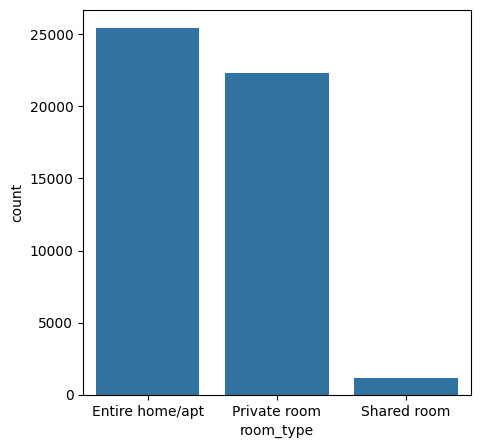

In [33]:
#Jumlah host per room type
plt.figure(figsize=(5,5))
sns.countplot(x=airbnb['room_type'])

<Axes: xlabel='room_type', ylabel='availability_365'>

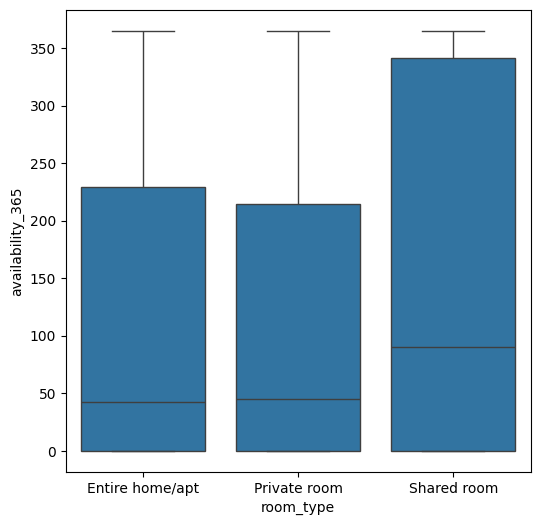

In [34]:
#Rata2, minimum, maksimum availability per room type
plt.figure(figsize=(6,6))
sns.boxplot(data=airbnb, x='room_type',y='availability_365')

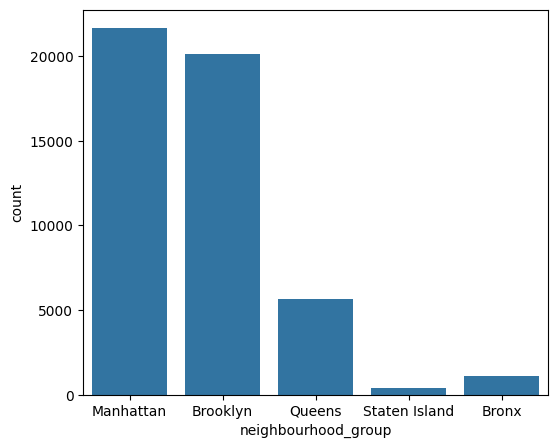

In [61]:
#Jumlah host per neighbourhood group
plt.figure(figsize=(6,5))
sns.countplot(data=airbnb, x='neighbourhood_group')
plt.show()

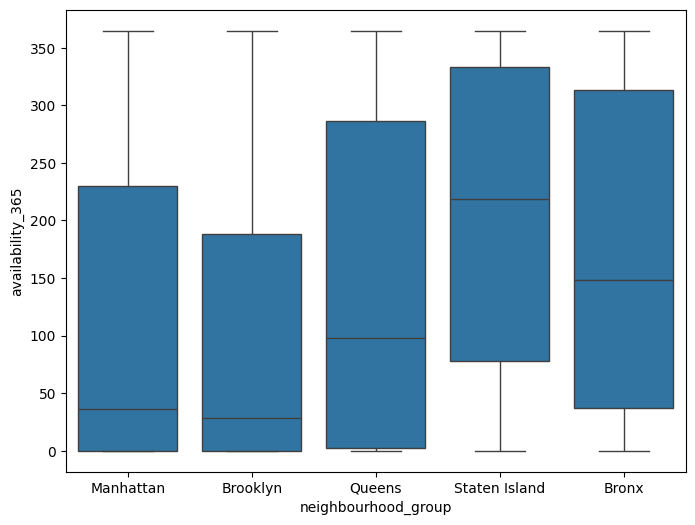

In [62]:
#Rata2, minimum, maksimum availability per neighbourhood_group

plt.figure(figsize=(8,6))
sns.boxplot(
    data=airbnb,
    x='neighbourhood_group',
    y='availability_365'
)
plt.show()

#Miscellaneous

##Menyimpan ke file

Menyimpan dataframe ke dalam file dilakukan dengan perintah `DataFrame.to_`*formatfile*


Misalnya, untuk menyimpan file ke format JSON, dapat dilakukan dengan `df.to_json(namafile)`

In [64]:
airbnb.head().to_json('json_val.json', orient='values') #other option : columns, records, split, index